<a href="https://colab.research.google.com/github/TaniaRua/coachella-sentiment-analysis/blob/main/SmartRetail_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


In [2]:
import os

os.listdir(path)

['Sample - Superstore.csv']

In [4]:
!pip install kagglehub pandas matplotlib seaborn plotly pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=03e21f6650e947bdfd4243679c1b98d90e3e8e353a35538affeb5a85da140b26
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [5]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandasql as ps
import os

In [27]:
archivo = path + "/Sample - Superstore.csv"
df = pd.read_csv(archivo, encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
---Visualizar Colomnas-----
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [18]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [19]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [21]:
df['Mes'] = df['Order Date'].dt.month

In [22]:
df['Dia'] = df['Order Date'].dt.day_name()

In [23]:
ventas_totales = df['Sales'].sum()

print("Ventas Totales:", round(ventas_totales, 2))

Ventas Totales: 2297200.86


In [24]:
ganancia_total = df['Profit'].sum()

print("Ganancia Total:", round(ganancia_total, 2))

Ganancia Total: 286397.02


In [25]:
regiones = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(regiones)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


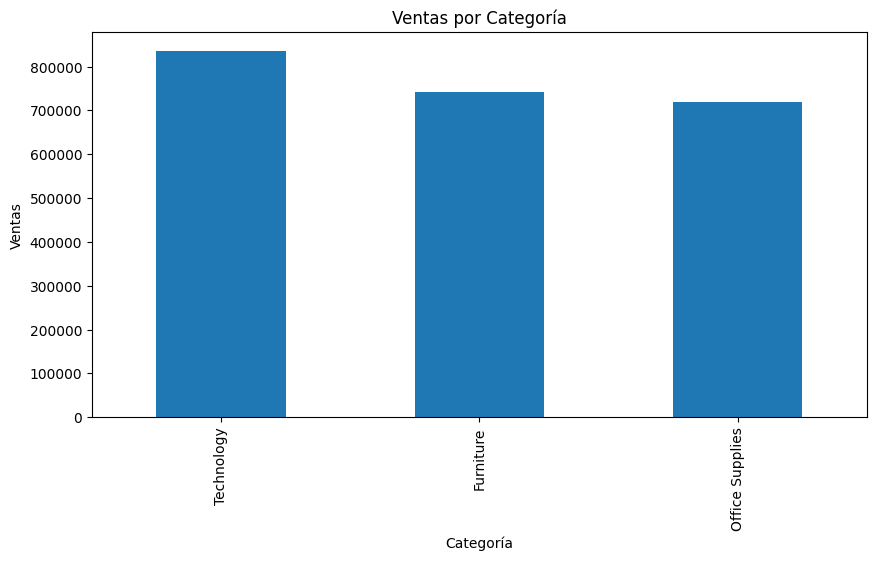

In [28]:
plt.figure(figsize=(10,5))

categorias = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
categorias.plot(kind='bar')

plt.title('Ventas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas')

plt.show()

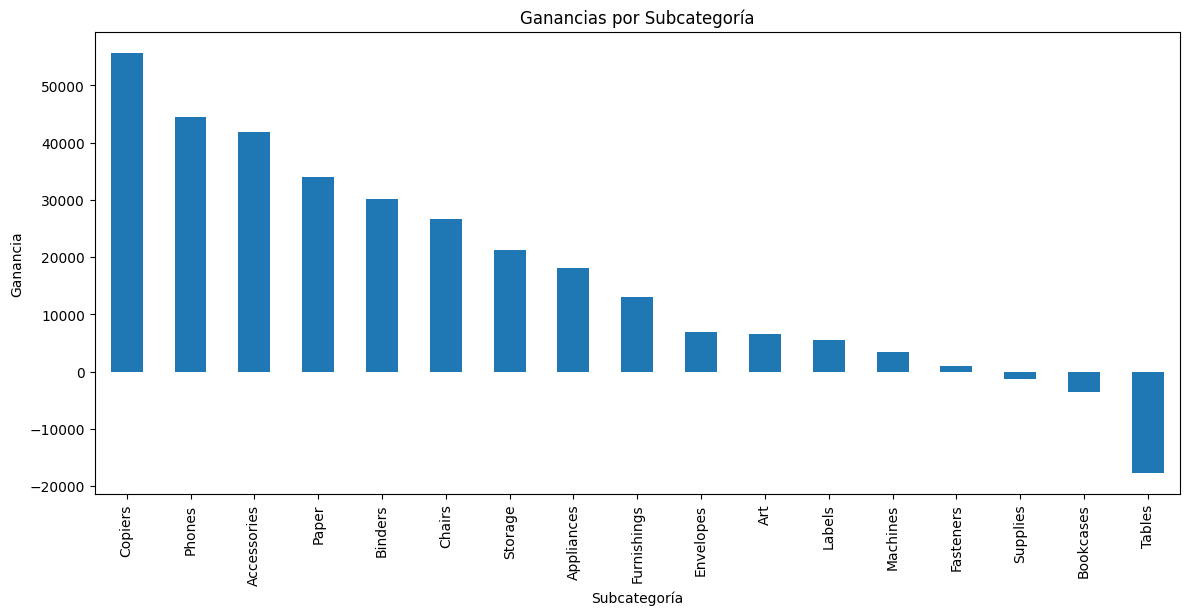

In [30]:
plt.figure(figsize=(14,6))

subcategorias = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
subcategorias.plot(kind='bar')

plt.title('Ganancias por Subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Ganancia')

plt.show()

In [31]:
fig = px.bar(
    df,
    x='Category',
    y='Sales',
    color='Region',
    title='Ventas por Categoría y Región'
)

fig.show()

In [32]:
fig = px.scatter(
    df,
    x='Sales',
    y='Profit',
    color='Category',
    size='Quantity',
    hover_data=['Sub-Category'],
    title='Ventas vs Ganancias'
)

fig.show()

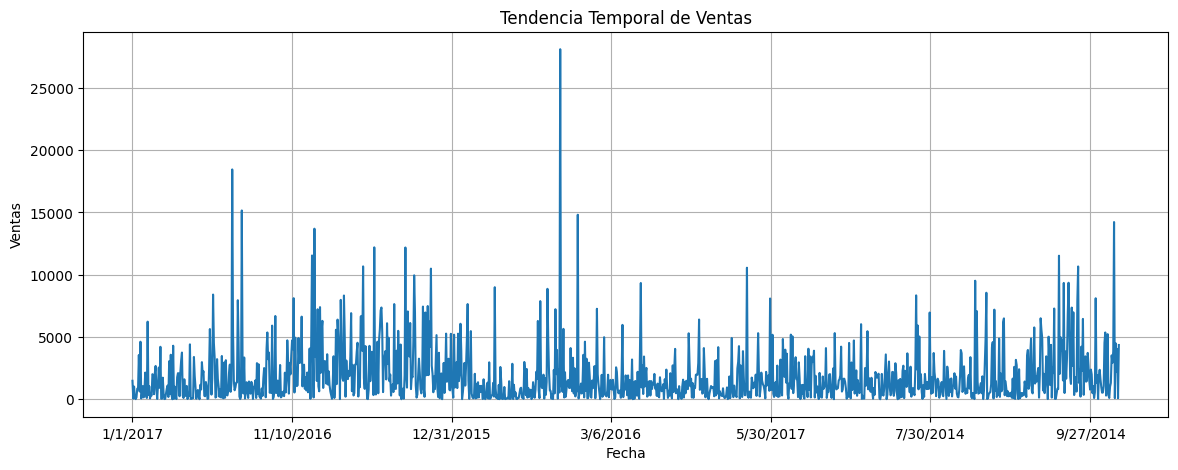

In [33]:
ventas_tiempo = (
    df.groupby('Order Date')['Sales']
    .sum()
)

plt.figure(figsize=(14,5))

ventas_tiempo.plot()

plt.title('Tendencia Temporal de Ventas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')

plt.grid(True)

plt.show()

In [34]:
query = '''
SELECT
    Region,
    SUM(Sales) AS ventas
FROM df
GROUP BY Region
ORDER BY ventas DESC
'''

resultado = ps.sqldf(query)

resultado

,Region,ventas
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [35]:
query2 = '''
SELECT
    "Customer Name",
    SUM(Sales) AS total_compras
FROM df
GROUP BY "Customer Name"
ORDER BY total_compras DESC
LIMIT 10
'''

top_clientes = ps.sqldf(query2)

top_clientes

,Customer Name,total_compras
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


In [36]:
query3 = '''
SELECT
    "Sub-Category",
    SUM(Quantity) AS total_vendido
FROM df
GROUP BY "Sub-Category"
ORDER BY total_vendido DESC
'''

productos_top = ps.sqldf(query3)

productos_top

,Sub-Category,total_vendido
0,Binders,5974
1,Paper,5178
2,Furnishings,3563
3,Phones,3289
4,Storage,3158
5,Art,3000
6,Accessories,2976
7,Chairs,2356
8,Appliances,1729
9,Labels,1400


In [38]:
print("SMARTRETAIL ANALYTICS")
print("----------------------")
print("Ventas Totales:", round(ventas_totales, 2))
print("Ganancia Total:", round(ganancia_total, 2))
promedio_ventas = df['Sales'].mean()
print("Promedio de Ventas:", round(promedio_ventas, 2))

SMARTRETAIL ANALYTICS
----------------------
Ventas Totales: 2297200.86
Ganancia Total: 286397.02
Promedio de Ventas: 229.86


A partir del análisis realizado sobre el conjunto de datos de ventas del hipermercado, se identifican diferentes patrones comerciales y comportamientos relevantes para la toma de decisiones empresariales.

El sistema registró unas ventas totales de 2,297,200.86 , mientras que la ganancia total obtenida fue de 286,397.02 , lo que evidencia que, aunque el volumen de ventas es alto, la utilidad representa una menor proporción debido a descuentos, costos y productos con baja rentabilidad. Además, el promedio de ventas por transacción fue de 229,86 , indicando un flujo constante de compras de valor medio.

En cuanto al análisis geográfico, la región Oeste presentó el mayor volumen de ventas con aproximadamente 725,457.82 , seguida de Oriente con 678,781.24 . Esto demuestra que estas regiones concentran la mayor actividad comercial y representan mercados estratégicos para la empresa. Por otro lado, la región Sur obtuvo el menor nivel de ventas, lo que podría indicar oportunidades de mejora en estrategias comerciales o menor demanda en esa zona.

El análisis por categorías mostró que ciertos grupos de productos generan mayores ingresos que otros, evidenciando diferencias claras en el comportamiento de compra de los clientes. Asimismo, el análisis de subcategorías permitió identificar productos altamente rentables y otros con ganancias reducidas, lo cual resulta útil para optimizar inventarios y estrategias de ventas.

Las visualizaciones temporales reflejaron fluctuaciones en las ventas a lo largo del tiempo, permitiendo identificar periodos de mayor actividad comercial y posibles temporadas de alta demanda. Además, el gráfico de relación entre ventas y ganancias mostró que no siempre un producto con altas ventas genera mayores beneficios, debido a factores como descuentos o márgenes de ganancia bajos.

Finalmente, mediante las consultas SQL se identifican los clientes con mayores volúmenes de compra y las subcategorías con más unidades vendidas, proporcionando información importante para estrategias de fidelización, segmentación de clientes y optimización comercial.